# Precipitation Trends MPI SSP245 (GCM & MAR-GCM)

#  (Annual and Seasonnal -original) 

## 1. Environnement

In [1]:
# import xarray as xr
import pandas as pd
import numpy as np
import calendar as cld
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.path import Path

from scipy.stats import linregress

#import geopandas as gpd
from pyproj import Proj, transform
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import shapefile
from copy import copy

/Users/peyaudv/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
# Which Computer ?
#path_DIR = '/bettik/beaumetj/'  # On dahu
path_DIR = '/Users/peyaudv/Glaciers/MAR_GCMs/' # Local pc perso
path_IMG = path_DIR+'SavedFigures/'

In [3]:
def get_slopes_and_pvalue_year(wp_meanyear):

    wp_meanyear_hist = wp_meanyear[:86,:,:]
#    wp_meanseason_fut = wp_meanseason[55:,:,:,:]
    
    origin_hist=np.full(wp_meanyear_hist.shape[1:4],np.nan)
    slope_hist=np.full(wp_meanyear_hist.shape[1:4],np.nan)
    pvalue_hist=np.full(wp_meanyear_hist.shape[1:4],np.nan)
    
#    origin_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    slope_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    pvalue_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    
    for i in range(wp_meanyear.shape[2]):
        # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
        for j in range(wp_meanyear.shape[1]):
            #for season in range(4):
                linregress_hist = linregress(np.arange(wp_meanyear_hist.shape[0]), wp_meanyear_hist[:,j,i])
                origin_hist[j][i] = linregress_hist.intercept
                slope_hist[j][i] = linregress_hist.slope
                pvalue_hist[j][i] = linregress_hist.pvalue
                
#                linregress_fut = linregress(np.arange(wp_meanseason_fut.shape[0]), wp_meanseason_fut[:,season,j,i])
#                origin_fut[season][j][i] = linregress_fut.intercept
#                slope_fut[season][j][i] = linregress_fut.slope
#                pvalue_fut[season][j][i] = linregress_fut.pvalue

#    return slope_hist, slope_fut, pvalue_hist, pvalue_fut
    return slope_hist, pvalue_hist

In [4]:
def get_slopes_and_pvalue_seas(wp_meanseason):

    wp_meanseason_hist = wp_meanseason[:86,:,:,:]
#    wp_meanseason_fut = wp_meanseason[55:,:,:,:]
    
    origin_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    slope_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    pvalue_hist=np.full(wp_meanseason_hist.shape[1:4],np.nan)
    
#    origin_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    slope_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
#    pvalue_fut=np.full(wp_meanseason_fut.shape[1:4],np.nan)
    
    for i in range(wp_meanseason.shape[3]):
        # print(str(lon)+'/'+str(les_season_maxT.shape[3]),end=' ')
        for j in range(wp_meanseason.shape[2]):
            for season in range(4):
                linregress_hist = linregress(np.arange(wp_meanseason_hist.shape[0]), wp_meanseason_hist[:,season,j,i])
                origin_hist[season][j][i] = linregress_hist.intercept
                slope_hist[season][j][i] = linregress_hist.slope
                pvalue_hist[season][j][i] = linregress_hist.pvalue
                
#                linregress_fut = linregress(np.arange(wp_meanseason_fut.shape[0]), wp_meanseason_fut[:,season,j,i])
#                origin_fut[season][j][i] = linregress_fut.intercept
#                slope_fut[season][j][i] = linregress_fut.slope
#                pvalue_fut[season][j][i] = linregress_fut.pvalue

#    return slope_hist, slope_fut, pvalue_hist, pvalue_fut
    return slope_hist, pvalue_hist

## 2. SSP 245

In [5]:
GCMname = 'MPI'
scenario = 'SSP245'

varnameShort = 'Prec'
varnameLong = 'Precipitation'

### 2.0 load Data

In [6]:
wp_mean_var_GCM = np.load(path_DIR+'numpyData/prec_MPI-ESM1-2-HR_SSP245'+'.npz')

In [7]:
print(wp_mean_var_GCM)

NpzFile '/Users/peyaudv/Glaciers/MAR_GCMs/numpyData/prec_MPI-ESM1-2-HR_SSP245.npz' with keys: T_month, T_season, T_year, lon, lat...


In [8]:
yearG=wp_mean_var_GCM['years']
longG=wp_mean_var_GCM['lon']
latiG=wp_mean_var_GCM['lat']
tmonG =wp_mean_var_GCM['T_month']
tsaiG =wp_mean_var_GCM['T_season']
tyeaG =wp_mean_var_GCM['T_year']

In [9]:
print(tsaiG.shape)

(86, 4, 7, 14)


In [10]:
wp_mean_var_MAR = np.load(path_DIR+'numpyData/prec_MARMPI-ESM1-2-HR_SSP245'+'.npz')

In [11]:
wp_mean_var_MAR['T_season'].shape

(86, 4, 91, 139)

In [12]:
yearM=wp_mean_var_MAR['years']
longM=wp_mean_var_MAR['lon']
latiM=wp_mean_var_MAR['lat']
tmonM =wp_mean_var_MAR['T_month']
tsaiM =wp_mean_var_MAR['T_season']
tyeaM =wp_mean_var_MAR['T_year']
#print(yearM)

In [13]:
WantedMassifPatches=[]
# Download and unzip shapefiles and open the desired one
shapes = shapefile.Reader("s2m_shapefiles/massifs_shapefiles/massifs_alpes_4226.shp")
patches = []
for shape in shapes.shapeRecords():
    massif_number = shape.record[0]
    massif_name = shape.record[1]
    polygon = Polygon(shape.shape.points, ec="none", fc="y", alpha=0.9)#, fill=False,facecolor='None')
    #print(shape.shape.points)
    patches.append(polygon)
    
    #print(shape.record[0],shape.record[1])
    if (massif_name=='Mont-Blanc'): 
        print(massif_name, massif_number)
        polygon_MB = Polygon(shape.shape.points, ec="none", fc="b", alpha=0.9)#, fill=False,facecolor='None')
    if (massif_name=='Vanoise'): 
        print(massif_name, massif_number)
        polygon_VA = Polygon(shape.shape.points, ec="none", fc="r", alpha=0.9)#, fill=False,facecolor='None')
    if (massif_name=='Oisans'): 
        print(massif_name, massif_number)
        polygon_OI = Polygon(shape.shape.points, ec="none", fc="g", alpha=0.9)#, fill=False,facecolor='None')
    if (massif_name=='Mont-Blanc' or massif_name=='Vanoise' or massif_name=='Oisans'):
        WantedMassifPatches.append([massif_name, massif_number])
print(WantedMassifPatches)

Mont-Blanc 3
Vanoise 10
Oisans 15
[['Mont-Blanc', 3], ['Vanoise', 10], ['Oisans', 15]]


### Find Glacioclim XY position

In [14]:
def findXYGlacioclim2 (lonGla,latGla,lonGrid2d,latGrid2d) :
# Find the speed at a certain lat/lon point.
    #Find the index of the grid point nearest a specific lat/lon.   
    abslat = np.abs(latGrid2d-latGla)
    abslon = np.abs(lonGrid2d-lonGla)
    c = np.maximum(abslon, abslat)
    # Return the grid point coordinates (x,y)
    ([xloc], [yloc]) = np.where(c == np.min(c))
    return (xloc, yloc) #([xloc], [yloc])

def findXYGlacioclim1 (lonGla,latGla,lonGrid1d,latGrid1d) :
# Find the speed at a certain lat/lon point.
    #Find the index of the grid point nearest a specific lat/lon.   
    abslat = np.abs(latGrid1d-latGla)
    abslon = np.abs(lonGrid1d-lonGla)
    xloc,yloc = np.where(abslon == np.min(abslon)), np.where(abslat == np.min(abslat))
    return (xloc[0].item(),yloc[0].item())#(xloc, yloc) #([xloc], [yloc])
    # use xloc[0].item() because np.where returns an ndarray

# Glacioclim glaciers location study (lon lat)
glacioClim=[["Argentiere",6.93,45.9], ["Mer de Glace",6.97,45.95], ["Gebroulaz",6.61,45.28], ["Saint Sorlin",6.63,45.15], ["Glacier Blanc",6.37,44.93]]

In [15]:
# X Y coordinates in MAR Grid 
glacioClXYG=[["Argentiere",0,0], ["Mer de Glace",0,0], ["Gebroulaz",0,0], ["Saint Sorlin",0,0], ["Glacier Blanc",0,0]]
glacioClXYM=[["Argentiere",0,0], ["Mer de Glace",0,0], ["Gebroulaz",0,0], ["Saint Sorlin",0,0], ["Glacier Blanc",0,0]]

for i in range(len(glacioClim)):
    #print (i,glacioClim[i][0])
    glacioClXYG[i][1],glacioClXYG[i][2] = findXYGlacioclim1(glacioClim[i][1],glacioClim[i][2],longG,latiG)
    glacioClXYM[i][1],glacioClXYM[i][2] = findXYGlacioclim2(glacioClim[i][1],glacioClim[i][2],longM,latiM)

In [16]:
print(glacioClXYG)

[['Argentiere', 3, 4], ['Mer de Glace', 3, 4], ['Gebroulaz', 3, 3], ['Saint Sorlin', 3, 3], ['Glacier Blanc', 3, 3]]


### 2.1 Plot (define colormap & range )

In [17]:
# Color scale for the notebook
#cmap, quality = plt.get_cmap('rainbow'), 100 
colo_scale = 'Blues'#colo_scale = 'rainbow'
vmin_scale, vmax_scale = 0., 1800.#-5., 25.
# Define a custom normalization for temperature range (optional)
norm = mcolors.Normalize(vmin=-5, vmax=25)
# Proj
proj = ccrs.PlateCarree()
quality = 100

In [18]:
if ((yearM[0]!=yearG[0])or(len(yearM)!=len(yearG))):
    print ("WARNING : yearM and yearG are different")
print(yearM)
#print(yearG)

[2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022. 2023. 2024. 2025. 2026.
 2027. 2028. 2029. 2030. 2031. 2032. 2033. 2034. 2035. 2036. 2037. 2038.
 2039. 2040. 2041. 2042. 2043. 2044. 2045. 2046. 2047. 2048. 2049. 2050.
 2051. 2052. 2053. 2054. 2055. 2056. 2057. 2058. 2059. 2060. 2061. 2062.
 2063. 2064. 2065. 2066. 2067. 2068. 2069. 2070. 2071. 2072. 2073. 2074.
 2075. 2076. 2077. 2078. 2079. 2080. 2081. 2082. 2083. 2084. 2085. 2086.
 2087. 2088. 2089. 2090. 2091. 2092. 2093. 2094. 2095. 2096. 2097. 2098.
 2099. 2100.]


In [19]:
print(longG)
print(longG.shape)
print(latiG.shape)
print(tyeaG.shape)
print(yearG)
print(tyeaG[0])
print(tyeaG[0].shape)

[ 3.75    4.6875  5.625   6.5625  7.5     8.4375  9.375  10.3125 11.25
 12.1875 13.125  14.0625 15.     15.9375]
(14,)
(7,)
(86, 7, 14)
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028
 2029 2030 2031 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042
 2043 2044 2045 2046 2047 2048 2049 2050 2051 2052 2053 2054 2055 2056
 2057 2058 2059 2060 2061 2062 2063 2064 2065 2066 2067 2068 2069 2070
 2071 2072 2073 2074 2075 2076 2077 2078 2079 2080 2081 2082 2083 2084
 2085 2086 2087 2088 2089 2090 2091 2092 2093 2094 2095 2096 2097 2098
 2099 2100]
[[1.21725161e-05 8.77216735e-06 9.65500203e-06 1.11365453e-05
  1.32766463e-05 1.14365694e-05 1.35645823e-05 1.70582407e-05
  2.14620468e-05 1.03240163e-05 1.19443475e-05 1.31672241e-05
  1.99183069e-05 1.37292072e-05]
 [1.14027107e-05 1.38256109e-05 1.30429316e-05 1.56196384e-05
  1.72908658e-05 1.39616013e-05 1.63488348e-05 2.28780900e-05
  1.48756844e-05 1.55980033e-05 1.63125715e-05 2.07547273e-05
  1.76698795e-05 3.14

In [20]:
year1,year2=0,80
date1,date2=int(yearG[0]+year1), int(yearG[0]+year2)

if (yearG[0]+year1 != yearM[0]+year1):
        print ('WARNING : date1M and date1G are different')

### 2.2 Plot january (selected years) 
### not done

### 2.3 Plot annual  (selected years)

Polygon43((6.17888, 45.8492) ...)


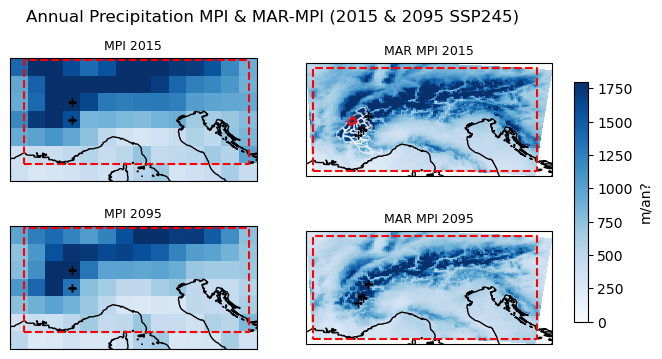

In [21]:
# Plot temperature pour 1er mois
fig, axs = plt.subplots(2, 2, figsize=(7, 4),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
#axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

axs[0,0].set_title(f"{GCMname} {date1}",fontsize=9)
axs[0,1].set_title(f"MAR {GCMname} {date1}",fontsize=9)
axs[1,0].set_title(f"{GCMname} {date2}",fontsize=9)
axs[1,1].set_title(f"MAR {GCMname} {date2}",fontsize=9)

# pcolormesh
m = axs[0,0].pcolormesh(
    longG, latiG, tyeaG[year1]*3600*24*365,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
m = axs[0,1].pcolormesh(
    longM, latiM, tyeaM[year1]*30, # pkoi 30 ????
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
# pcolormesh
m = axs[1,0].pcolormesh(
    longG, latiG, tyeaG[year2]*3600*24*365,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
m = axs[1,1].pcolormesh(
    longM, latiM, tyeaM[year2]*30,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)

axs[0,0].add_feature(cfeature.COASTLINE)
axs[0,1].add_feature(cfeature.COASTLINE)
axs[1,0].add_feature(cfeature.COASTLINE)
axs[1,1].add_feature(cfeature.COASTLINE)
axs[0,0].plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
axs[0,1].plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
axs[1,0].plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
axs[1,1].plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())
#for i, ax in enumerate(axs):
#   ax.add_feature(cfeature.COASTLINE) # Does not work
   # Tracé du polygone en pointillés rouge
   #ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r')#, transform=ccrs.PlateCarree())

# Position des glaciers
for i in range(len(glacioClim)):
    # Data GCM 2 vector coordinates LON & LAT
    # Data MAR 2 matrix coordinates (LON,LAT)
    xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]
    xM, yM = glacioClXYM[i][1], glacioClXYM[i][2]
    axs[0,0].plot(longG[xG],latiG[yG], marker='+',color='black')
    axs[0,1].plot(longM[xM][yM],latiM[xM][yM], marker='+',color='black')
    axs[1,0].plot(longG[xG],latiG[yG], marker='+',color='black')
    axs[1,1].plot(longM[xM][yM],latiM[xM][yM], marker='+',color='black')
# 3. Plot shapefiles massifs alpes
if (True):
    collection = PatchCollection(patches)
    collection.set_color('none')
    collection.set_edgecolor('w')
    collection.set_alpha(0.6)
#    collection1 = PatchCollection(patches)
#    axs[0].add_collection(collection)
    axs[0,1].add_collection(collection)

#Massif Mont Blanc
print(patches[3])
axs[0,1].plot(patches[3].get_xy()[:, 0],patches[3].get_xy()[:, 1],color='red')
# Horizontal colorbar
cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
fig.colorbar(m, cax=cbar_ax, orientation='vertical', label='m/an?')

fig.suptitle(f"Annual {varnameLong} {GCMname} & MAR-{GCMname} ({date1} & {date2} {scenario})", fontsize=12)
plt.savefig(f"{path_IMG}{GCMname}_MAR_{scenario}_{varnameShort}_year{date1}and{date2}.png")

### 2.4 Plot seasonnal

In [22]:
labelseasons = ["DJF", "MAM", "JJA", "SON"]

2015


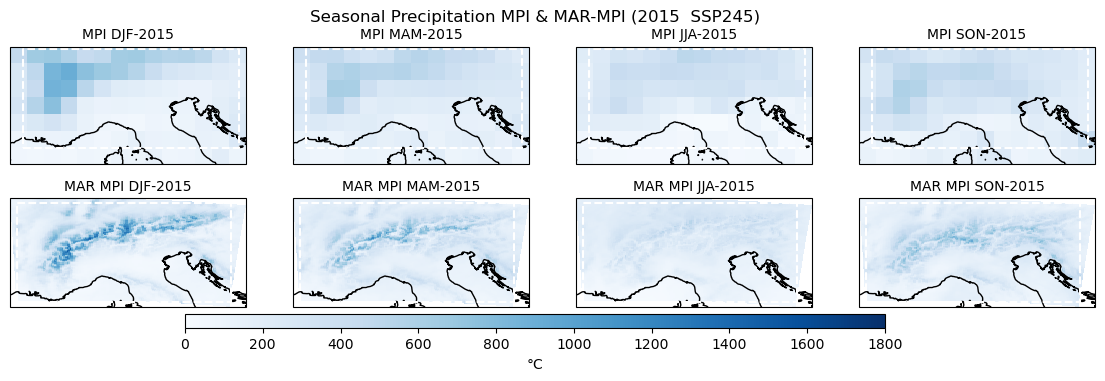

In [23]:
# Plot temperature for date1
date=date1
year=year1
print(date)

fig, axs = plt.subplots(2, 4, figsize=(14, 3.5),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
#axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

for s in range(len(labelseasons)):
    #print(i,saisons[i])
    # ----- GCM -----
    ax = axs[0, s]
    ax.set_title(f"{GCMname} {labelseasons[s]}-{date}",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, tsaiG[year,s]*3600*24*91,#365, #91 day in a season
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    # ----- MAR -----
    ax = axs[1, s]
    ax.set_title(f"MAR {GCMname} {labelseasons[s]}-{date}",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longM, latiM, tsaiM[year,s]*30,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')

fig.suptitle(f'Seasonal {varnameLong} {GCMname} & MAR-{GCMname} ({date}  {scenario})', fontsize=12)
plt.savefig(f'{path_IMG}{GCMname}-MAR_{scenario}_{varnameShort}_season_{date}.png')

2095


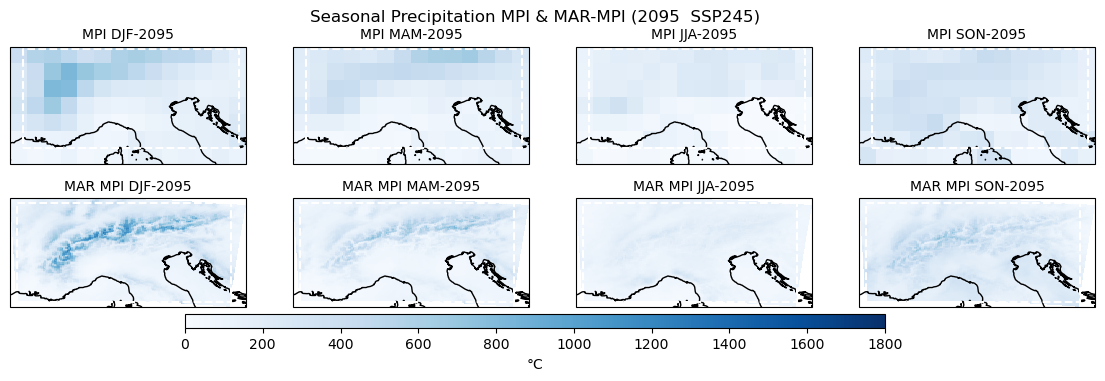

In [24]:
# Plot temperature for date1
date=date2
year=year2
print(date)

fig, axs = plt.subplots(2, 4, figsize=(14, 3.5),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
#axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

for s in range(len(labelseasons)):
    #print(i,saisons[i])
    # ----- GCM -----
    ax = axs[0, s]
    ax.set_title(f"{GCMname} {labelseasons[s]}-{date}",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longG, latiG, tsaiG[year,s]*3600*24*91,#365, #91 day in a season
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())
    # ----- MAR -----
    ax = axs[1, s]
    ax.set_title(f"MAR {GCMname} {labelseasons[s]}-{date}",fontsize=10)
    # pcolormesh
    m = ax.pcolormesh(
    longM, latiM, tsaiM[year,s]*30,
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--w', transform=ccrs.PlateCarree())

# Horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.04])
fig.colorbar(m, cax=cbar_ax, orientation='horizontal', label='°C')

fig.suptitle(f'Seasonal {varnameLong} {GCMname} & MAR-{GCMname} ({date}  {scenario})', fontsize=12)
plt.savefig(f'{path_IMG}{GCMname}-MAR_{scenario}_{varnameShort}_season_{date}.png')

### 2.4 Plot annual trends

In [25]:
# Seasonnal Temperature trend for GCM
slopeT_yG, pvalue = get_slopes_and_pvalue_year(tyeaG/tyeaG[0])

In [26]:
print(slopeT_yG.shape) # seasons, lon, lat

(7, 14)


In [27]:
# Seasonnal  Temperature trend for MAR
slopeT_yM, pvalue = get_slopes_and_pvalue_year(tyeaM/tyeaM[0])

In [28]:
print(slopeT_yM.shape) # seasons, lon, lat

(91, 139)


In [29]:
# Color scale
colo_scale = 'BrBG'
vmin_scale, vmax_scale = -0.2, 0.2

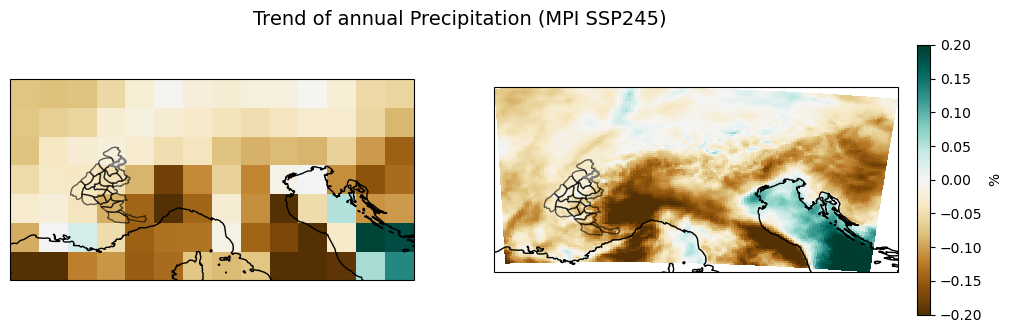

In [30]:
# Plot trends for seasonal temperature for run GCM and MAR
fig, axs = plt.subplots(nrows=1, ncols=2,figsize=(12, 3.5),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)
# Boucle principale
#for i in range(4):
#    pcm = ax.pcolormesh(Long, Lati, slope_T_hist[i], cmap='rainbow', vmin=-1., vmax=1.
#) ### Comment otherwise it shifts the panels

# ----- GCM -----
ax = axs[0]
    #print("hist",slope_T_hist[i,0,0])
cb = ax.pcolormesh(longG, latiG, 100*slopeT_yG, # 100*slope_T_hist[i] ????????
                   cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
#ax.text(5, 47.5, f"{np.mean(slope_TG[i]):.3f}",
#        ha='center', va='center', fontsize=10)
ax.add_feature(cfeature.COASTLINE)
    
# ----- MAR -----
ax = axs[1]
    #print("245",slope_T_245[i,0,0])
ax.pcolormesh(longM, latiM, 100*slopeT_yM,
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
#ax.text(5, 47.5, f"{np.mean(slope_TM[i]):.3f}",
#            ha='center', va='center', fontsize=10)
ax.add_feature(cfeature.COASTLINE)

# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("%")
#cbar.set_ticks(np.linspace(0, 8, 9))

# ----- Titres colonnes -----
#axs[0].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i].yaxis.set_ticks_position('right')
    axs[i].set_ylabel(label, fontsize=14, rotation=90)
axs[1].set_ylabel(label, fontsize=14, rotation=90)

# 3. Plot shapefiles massifs alpes
if (True):
    collection = PatchCollection(patches)
    collection.set_color('none')
    collection.set_edgecolor('k')
    collection.set_alpha(0.6)
    axs[0].add_collection(collection)
    #must copy the paches to recreate a new Artist view
    new_patches=copy(patches)
    collection1 = PatchCollection(new_patches)
    collection1.set_color('none')
    collection1.set_edgecolor('k')
    collection1.set_alpha(0.6)
    axs[1].add_collection(collection1)

# Plot Mont Blanc in red
i_ployg=2 
axs[0].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')
axs[1].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')

fig.suptitle(f"Trend of annual {varnameLong} ({GCMname} {scenario})", fontsize=14)
plt.savefig(f"{path_IMG}MAR_{scenario}_Trend_{varnameShort}_{yearM[0]}-{yearM[-1]}.png")

In [31]:
i=1 #MdG
xlonG, ylatG = glacioClXYG[i][1], glacioClXYG[i][2]

# Temperature trend GCM
print(xG,yG,100*slopeT_yM[ylatG,xlonG])
print(xG,yG,100*slopeT_yM[ylatG+1,xlonG])

3 3 -0.09058687775740737
3 3 -0.08992454756691198


In [32]:
# Color scale
colo_scale = 'BrBG'
vmin_scale, vmax_scale = -0.2, 0.2

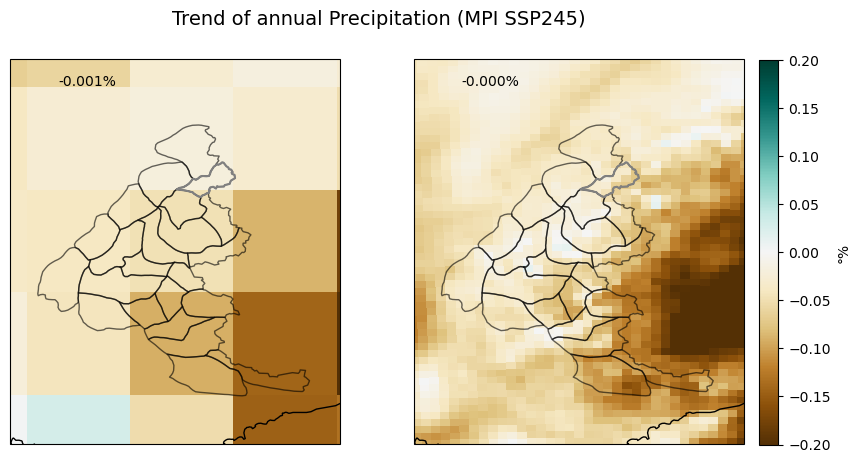

In [33]:
from copy import copy

# Plot trends for seasonal temperature for run GCM and MAR
fig, axs = plt.subplots(nrows=1, ncols=2,figsize=(10, 5),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)
# Boucle principale
#for i in range(4):
#    pcm = ax.pcolormesh(Long, Lati, slope_T_hist[i], cmap='rainbow', vmin=-1., vmax=1.
#) ### Comment otherwise it shifts the panels

# ----- GCM -----
ax = axs[0]
    #print("hist",slope_T_hist[i,0,0])
cb = ax.pcolormesh(longG, latiG, 100*slopeT_yG, # 100*slope_T_hist[i] ????????
                   cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.text(5.7, 46.8, f"{np.mean(slopeT_yG[i]):.3f}%",
        ha='center', va='center', fontsize=10)
ax.add_feature(cfeature.COASTLINE)
    
# ----- MAR -----
ax = axs[1]
    #print("245",slope_T_245[i,0,0])
ax.pcolormesh(longM, latiM, 100*slopeT_yM,
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.text(5.7, 46.8, f"{np.mean(slopeT_yM[i]):.3f}%",
            ha='center', va='center', fontsize=10)
ax.add_feature(cfeature.COASTLINE)

# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("°%")
#cbar.set_ticks(np.linspace(0, 8, 9))

# ----- Titres colonnes -----
#axs[0].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i].yaxis.set_ticks_position('right')
    axs[i].set_ylabel(label, fontsize=14, rotation=90)
    
    axs[i].set_xlim(5,8)
    axs[i].set_ylim(43.5,47)

# 3. Plot shapefiles massifs alpes
if (True):
    collection2 = PatchCollection(patches)
    collection2.set_color('none')
    collection2.set_edgecolor('k')
    collection2.set_alpha(0.6)

    #must copy the paches to recreate a new Artist view
    new_patches=copy(patches)
    collection3 = PatchCollection(new_patches)
    collection3.set_color('none')
    collection3.set_edgecolor('k')
    collection3.set_alpha(0.6)
axs[0].add_collection(collection2)
axs[1].add_collection(collection3)


# Plot Mont Blanc in red
i_ployg=2 
axs[0].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')
axs[1].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')

fig.suptitle(f"Trend of annual {varnameLong} ({GCMname} {scenario})", fontsize=14)
plt.savefig(f"{path_IMG}{GCMname}_MAR_{scenario}_Trend_{varnameShort}_{yearM[0]}-{yearM[-1]}_Zoom.png")

In [34]:
i=1 #MdG
xlonG, ylatG = glacioClXYG[i][1], glacioClXYG[i][2]

# Temperature trend GCM
print(xG,yG,100*slopeT_yG[ylatG,xlonG])
print(xG,yG,100*slopeT_yG[ylatG+1,xlonG])

3 3 -0.0190726561478294
3 3 -0.028694079711750413


### 2.6 Plot seasonnal trends 

In [35]:
# Seasonnal trend for GCM
slopeT_sG, pvalue = get_slopes_and_pvalue_seas(tsaiG/tsaiG[0])

print(slopeT_sG.shape) # seasons, lon, lat

# Seasonnal trend for MAR
slopeT_sM, pvalue = get_slopes_and_pvalue_seas(tsaiM/tsaiM[0])

print(slopeT_sM.shape) # seasons, lon, lat

(4, 7, 14)
(4, 91, 139)


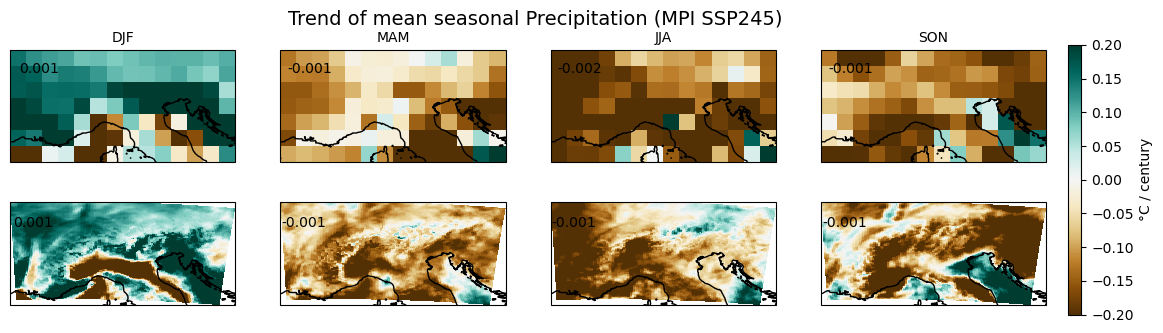

In [36]:
# Plot trends for seasonal temperature for run GCM and MAR
fig, axs = plt.subplots(nrows=2, ncols=4,figsize=(14, 3.5),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)

# Boucle principale
for i in range(4):
#    pcm = ax.pcolormesh(Long, Lati, slope_T_hist[i], cmap='rainbow', vmin=-1., vmax=1.
#) ### Comment otherwise it shifts the panels

    # ----- GCM -----
    ax = axs[0, i]
    #print("hist",slope_T_hist[i,0,0])
    cb = ax.pcolormesh(longG, latiG, 100*slopeT_sG[i], # 100*slope_T_hist[i] ????????
                       cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
    ax.text(5, 47.5, f"{np.mean(slopeT_sG[i]):.3f}",
            ha='center', va='center', fontsize=10)
    ax.add_feature(cfeature.COASTLINE)
    
    # ----- MAR -----
    ax = axs[1, i]
    #print("245",slope_T_245[i,0,0])
    ax.pcolormesh(longM, latiM, 100*slopeT_sM[i],
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
    ax.text(5, 47.5, f"{np.mean(slopeT_sM[i]):.3f}",
            ha='center', va='center', fontsize=10)
    ax.add_feature(cfeature.COASTLINE)

# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("°C / century")
#cbar.set_ticks(np.linspace(0, 8, 9))

# ----- Titres colonnes -----
for i, label in enumerate(["DJF", "MAM", "JJA", "SON"]):
    axs[0, i].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i, 0].yaxis.set_ticks_position('right')
    axs[i, 0].set_ylabel(label, fontsize=14, rotation=90)
axs[1, 1].set_ylabel(label, fontsize=14, rotation=90)

fig.suptitle(f"Trend of mean seasonal {varnameLong} ({GCMname} {scenario})", fontsize=14)
plt.savefig(f"{path_IMG}{GCMname}-MAR_{scenario}_{varnameShort}_Trend_season_{int(yearM[0])}-{int(yearM[-1])}.png")

Mer de Glace 3 4
s,slopeT_sG[s,4,3]
0 0.001550987326369493
1 -0.0010947575526564154
2 -0.0016273280760050323
3 -0.0009142993464985283


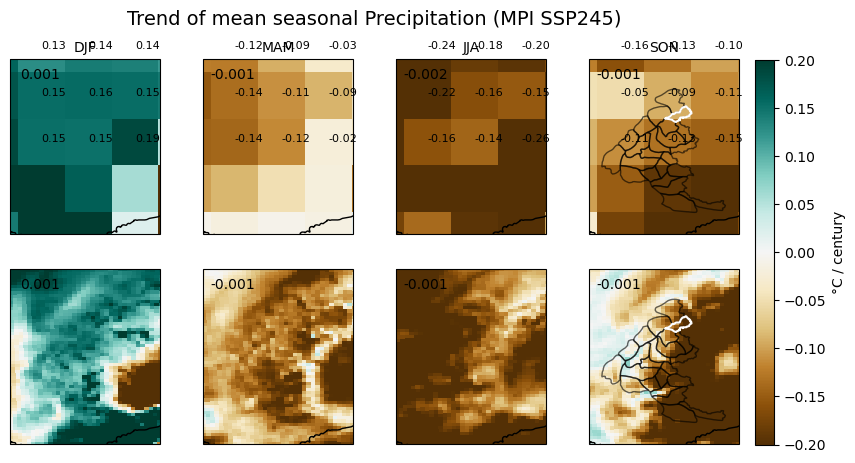

In [37]:
print(glacioClXYG[1][0],glacioClXYG[1][1], glacioClXYG[1][2])
print(f's,slopeT_sG[s,{glacioClXYG[1][2]},{glacioClXYG[1][1]}]')
# Plot trends for seasonal temperature for run GCM and MAR
fig, axs = plt.subplots(nrows=2, ncols=4,figsize=(10, 5),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)

# Boucle principale
for s in range(4):
#    pcm = ax.pcolormesh(Long, Lati, slope_T_hist[i], cmap='rainbow', vmin=-1., vmax=1.
#) ### Comment otherwise it shifts the panels

    # ----- GCM -----
    ax = axs[0, s]
    #print("hist",slope_T_hist[i,0,0])
    cb = ax.pcolormesh(longG, latiG, 100*slopeT_sG[s], # 100*slope_T_hist[i] ????????
                       cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
    ax.text(5.6, 46.7, f"{np.mean(slopeT_sG[s]):.3f}",
            ha='center', va='center', fontsize=10)
    ax.add_feature(cfeature.COASTLINE)
    
    ax.set_xlim(5,8)
    ax.set_ylim(43.5,47)
    
    ############# write values around MdG ####
    print(s,slopeT_sG[s, glacioClXYG[1][2],glacioClXYG[1][1]])
    for ii in np.arange(-1,2):
        for jj in np.arange(-1,2):
            ilat, jlon = glacioClXYG[1][1]+ii, glacioClXYG[1][2]+jj 
            #print(longG[glacioClXYG[1][1]+ii], latiG[glacioClXYG[1][2]+jj], f'{100*slopeT_sG[i,glacioClXYG[1][1]+ii,glacioClXYG[1][2]+jj]}')
            ax.text(longG[ilat], latiG[jlon], f'{100*slopeT_sG[s,jlon,ilat]:.2f}',fontsize=8)
    
    # ----- MAR -----
    ax = axs[1, s]
    #print("245",slope_T_245[i,0,0])
    ax.pcolormesh(longM, latiM, 100*slopeT_sM[s],
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
    ax.text(5.6, 46.7, f"{np.mean(slopeT_sM[s]):.3f}",
            ha='center', va='center', fontsize=10)
    ax.add_feature(cfeature.COASTLINE)
    
        
    ax.set_xlim(5,8)
    ax.set_ylim(43.5,47)
    
# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("°C / century")
#cbar.set_ticks(np.linspace(0, 8, 9))

# ----- Titres colonnes -----
for s, label in enumerate(["DJF", "MAM", "JJA", "SON"]):
    axs[0, s].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i, 0].yaxis.set_ticks_position('right')
    axs[i, 0].set_ylabel(label, fontsize=14, rotation=90)
axs[1, 1].set_ylabel(label, fontsize=14, rotation=90)

# 3. Plot shapefiles massifs alpes
if (True):
    collection2 = PatchCollection(patches)
    collection2.set_color('none')
    collection2.set_edgecolor('k')
    collection2.set_alpha(0.6)

    #must copy the paches to recreate a new Artist view
    new_patches=copy(patches)
    collection3 = PatchCollection(new_patches)
    collection3.set_color('none')
    collection3.set_edgecolor('k')
    collection3.set_alpha(0.6)
axs[0,3].add_collection(collection2)
axs[1,3].add_collection(collection3)

# Plot Mont Blanc in red
i_ployg=2 
axs[0,3].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='w')
axs[1,3].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='w')

fig.suptitle(f"Trend of mean seasonal {varnameLong} ({GCMname} {scenario})", fontsize=14)
plt.savefig(f"{path_IMG}{GCMname}-MAR_{scenario}_{varnameShort}_Trend_season_{int(yearM[0])}-{int(yearM[-1])}_zoom.png")

## 3. Compare on same grid

See https://github.com/Ian-CD/PhD/blob/master/Article_EDW/Figs_1_and_2_and_appendixB.ipynb,
Article from Ian (https://egusphere.copernicus.org/preprints/2025/egusphere-2025-6211/egusphere-2025-6211.pdf)

### 3.1 On MAR Grid

In [38]:
# To Do 
# see 3-plot-MPI-trend_seasonal_v1.ipynb

### 3.2 On GCM Grid

In [39]:
colmap = 'hot_r'
slope_TMonG = np.zeros(np.shape(slopeT_yG))

### At Glacioclim location 

In [40]:
# number of years
print(yearG[-1],yearG[0])
yearG[-1]-yearG[0]+1
nby=int(yearG[-1].item()-yearG[0].item()+1)

2100 2015


In [41]:
# Calculate average on a given period

#Define period for mean calculation
first_year_mean, last_year_mean = 2015, 2099 # 1960, 1990
temp = np.where( yearM == np.min(first_year_mean) ) # index of meantime first year in array of years
iy_i = temp[0].item()
temp = np.where( yearM == np.min(last_year_mean)  ) # index of meantime last...
iy_f = temp[0].item()
print(f"Index first, last years: {iy_i}, {iy_f}")

# Annual Temperature
glacioClT_yearG = np.zeros((nby,5)) # GCM
glacioClT_yearM = np.zeros((nby,5)) # MAR
# Seasonnal Temperature
glacioClT_seasG = np.zeros((nby,5,4))
glacioClT_seasM = np.zeros((nby,5,4))

# Mean Annual Temperature
glacioClTmean_yearG = np.zeros(5)
glacioClTmean_yearM = np.zeros(5)
# Mean Seasonnal Temperature
glacioClTmean_seasG = np.zeros((5,4))
glacioClTmean_seasM = np.zeros((5,4))
#glacioClTmean_seasG

Index first, last years: 0, 84


In [42]:
tmonG.shape

(86, 12, 7, 14)

In [43]:
tmonG[iy_i:iy_f,:,0,0].shape

(84, 12)

In [44]:
# Position des glaciers
for i in range(len(glacioClim)):
    # Data GCM 2 vector coordinates LON & LAT
    # Data MAR 2 matrix coordinates (LON,LAT)
    xlonG, ylatG = glacioClXYG[i][1], glacioClXYG[i][2]
    xlonM, ylatM = glacioClXYM[i][1], glacioClXYM[i][2]

    # Year Temp
    glacioClT_yearG[:,i] = tyeaG[:,ylatG,xlonG]
    glacioClT_yearM[:,i] = tyeaM[:,ylatM,xlonM]
    
    # Mean Year Temp
    glacioClTmean_yearG[i] = np.average(tyeaG[iy_i:iy_f,ylatG,xlonG])
    glacioClTmean_yearM[i] = np.average(tyeaM[iy_i:iy_f,ylatM,xlonM])
    
    # Month Temp
#    for y in range(len(yearG)):
#        glacioClT_monG[y,i] = np.average(tmonG[y,:,xG,yG])
#        glacioClT_monM[y,i] = np.average(tmonM[y,:,xM,yM])

    # Mean Month Temp
#    glacioClTmean_monG[i] = np.average(tmonG[iy_i:iy_f,:,xG,yG])
#    glacioClTmean_monM[i] = np.average(tmonM[iy_i:iy_f,:,xM,yM])
    
    # Seasonnal Temp
    for y in range(len(yearG)):    
        #print(tsaiG[y,:,xG,yG])
        glacioClT_seasG[y,i,:] = tsaiG[y,:,ylatG,xlonG]
        glacioClT_seasM[y,i,:] = tsaiM[y,:,ylatM,xlonM]
    # Season,nal Temp
    for s in range(4):
        glacioClTmean_seasG[i][s] = np.average(tsaiG[iy_i:iy_f,s,ylatG,xlonG]) 
        glacioClTmean_seasM[i][s] = np.average(tsaiM[iy_i:iy_f,s,ylatG,xlonG])
    #print(i,xM, yM, glacioClTmean_seasG[i], glacioClTmean_seasM[i])

In [45]:
glacioClT_seasM

array([[[ 3.25460291,  7.14873981,  5.58460379,  4.9907527 ],
        [ 3.25460291,  7.14873981,  5.58460379,  4.9907527 ],
        [ 9.88054085, 10.37488556, 11.64431667,  8.04588223],
        [ 6.79635525,  5.4830265 ,  6.9701314 ,  4.90400505],
        [10.68516541,  5.50649261,  3.89963007,  9.05005646]],

       [[ 4.31065559,  2.61371517,  2.20359111,  8.458848  ],
        [ 4.31065559,  2.61371517,  2.20359111,  8.458848  ],
        [ 9.90143394,  7.53888226,  3.05650663, 14.16229153],
        [ 4.29329014,  4.15686512,  2.55999088,  8.57334137],
        [ 6.44972038,  2.00849247,  2.12497711, 14.82062912]],

       [[ 3.52603459, 14.60433388,  5.29143572,  6.14205694],
        [ 3.52603459, 14.60433388,  5.29143572,  6.14205694],
        [12.78418159, 23.43405914,  6.91342926, 12.22485065],
        [ 8.36218834, 12.27980804,  4.15207481,  7.20228958],
        [13.05655861,  9.65155506,  2.92886949,  7.79102707]],

       ...,

       [[ 2.77867579,  3.71475029,  3.77173567,  7.

In [46]:
#print(tmonG[iy_i:iy_f,:,xG,yG])
#print(tmonM[iy_i:iy_f,:,xM,yM])

In [47]:
print("Check the size of data Array:")
print(tmonG.shape)
print(tsaiG.shape)
print(glacioClTmean_yearM.shape)
print(glacioClTmean_seasM.shape)
print(glacioClT_seasM.shape)

Check the size of data Array:
(86, 12, 7, 14)
(86, 4, 7, 14)
(5,)
(5, 4)
(86, 5, 4)


In [48]:
# Plot 1 : massif du Mont Blanc 4 saisons
print("glacioClT_yearG : GCM Annual and Mean Temp at all glacioclim location:")
print(glacioClT_yearG.shape)
print(glacioClTmean_yearG.shape)

glacioClT_yearG : GCM Annual and Mean Temp at all glacioclim location:
(86, 5)
(5,)


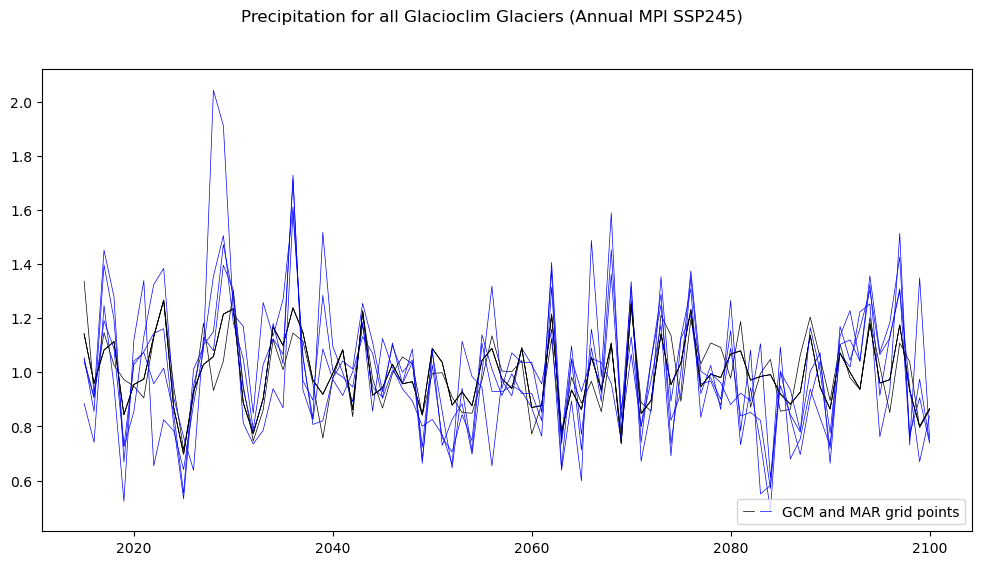

In [49]:
#Plot temperatures mensuelles pour 4 glacier
from matplotlib.legend_handler import HandlerTuple

fig, ax = plt.subplots(1, figsize=(12, 6))
for i in range(4):
    ii=i+1
    glaName,xloc,yloc = glacioClXYG[ii][:] # ii=i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
    xG, yG = glacioClXYG[ii][1], glacioClXYG[ii][2]
    xM, yM = glacioClXYM[ii][1], glacioClXYM[ii][2]

    line1, = ax.plot(yearG,glacioClT_yearG[:,ii]/glacioClTmean_yearG[ii],'k',lw=0.5)        # 
    line2, = ax.plot(yearG,glacioClT_yearM[:,ii]/glacioClTmean_yearM[ii],'b',lw=0.5)        # 

    # Creating custom legend handles
handles = [(line1, line2)]
labels = ['GCM and MAR grid points']
# Adding the custom legend
ax.legend(handles, labels, handler_map={tuple: HandlerTuple(ndivide=None)},loc='lower right')   

fig.suptitle(f"{varnameLong} for all Glacioclim Glaciers (Annual {GCMname} {scenario})", fontsize=12)
plt.savefig(f"{path_IMG}{varnameShort}_all_Glacioclim_Glaciers_Annual_{GCMname}_{scenario}.png")

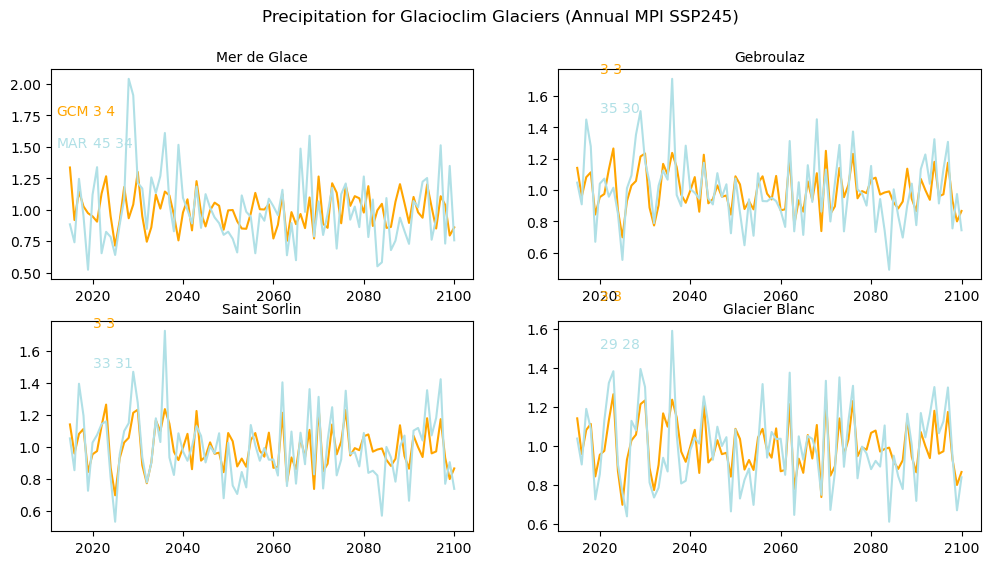

In [50]:
# Computing trends for all Glacioclim glacier (Temperature linear regression)
slope_T_loc=np.full(5,np.nan)
pvalue_T_loc=np.full(5,np.nan)
intercept_T_loc=np.full(5,np.nan)

#Plot temperatures mensuelles pour 4 glacier
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs = axs.ravel()



for i, ax in enumerate(axs):
    ii=i+1
    glaName,xloc,yloc = glacioClXYG[ii][:] # ii=i+1 because 5 glaciers and 2 first are in same pixel (Arg and MdG)
    xG, yG = glacioClXYG[ii][1], glacioClXYG[ii][2]
    xM, yM = glacioClXYM[ii][1], glacioClXYM[ii][2]

    
    ax.plot(yearG,glacioClT_yearG[:,ii]/glacioClTmean_yearG[ii],color='orange')      # T Ann
    ax.plot(yearG,glacioClT_yearM[:,ii]/glacioClTmean_yearM[ii],color='powderblue')        # T Ann
    ax.text(2020,1.75,f'{xG} {yG}',color='orange')
    ax.text(2020,1.50,f'{xM} {yM}',color='powderblue')    
    #ax.plot(yearG,glacioClT_yearM[:,ii])        # T Ann

    #print(glacioClTmean_yearG[ii])
    #print(np.mean(tannG[:,1,xG,yG]))
    # Computing trends

    
    ax.set_title(glaName,fontsize=10)

axs[0].text(2012,1.75,'GCM',color='orange')
axs[0].text(2012,1.50,'MAR',color='powderblue')

fig.suptitle(f"{varnameLong} for Glacioclim Glaciers (Annual {GCMname} {scenario})", fontsize=12)
plt.savefig(f"{path_IMG}{varnameShort}_Glacioclim_Glaciers_Annual_{GCMname}_{scenario}.png")

### Seasonnal

In [51]:
labelseasons = ["DJF", "MAM", "JJA", "SON"]

0 DJF
1 MAM
2 JJA
3 SON


Text(0.5, 0.98, 'Precipitation  for all Glacioclim Glaciers (MPI SSP245 ?????????)')

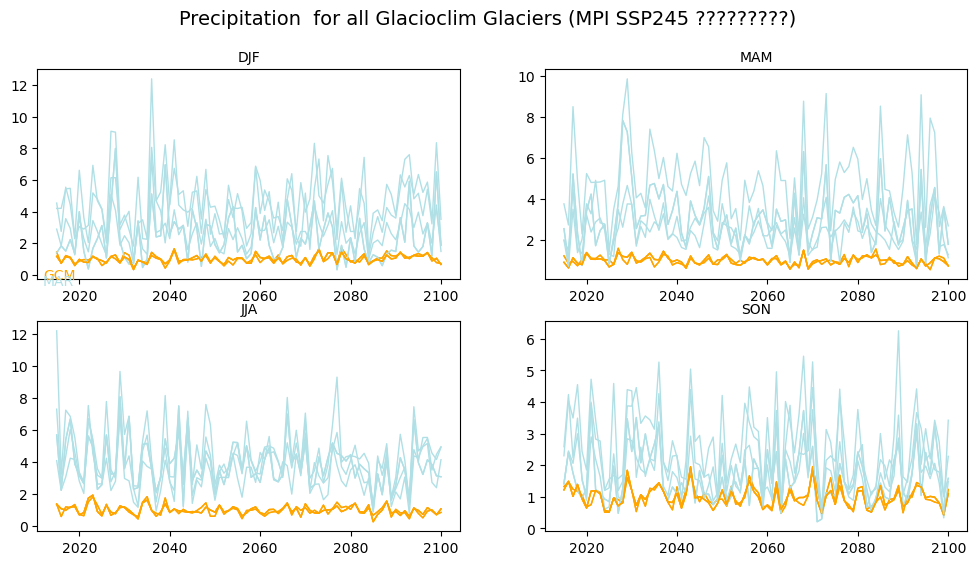

In [52]:
#Plot temperatures mensuelles pour 4 glacier
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs.ravel()

s = 0 # seasons

for i in range(len(axs)):
    for j in range(len(axs[0])):
        label = labelseasons[s]
        print(s, label)
        ax = axs[i][j]
        ax.set_title(labelseasons[s], fontsize=10)
        for ii in range(len(glacioClXYG)):
            ax.plot(yearG,glacioClT_seasG[:,ii,s]/glacioClTmean_seasG[ii,s],'orange',lw=1) 
            ax.plot(yearG,glacioClT_seasM[:,ii,s]/glacioClTmean_seasM[ii,s],color='powderblue',lw=1)
            #ax.plot(yearG,glacioClT_seasG[:,ii,s]-glacioClTmean_seasG[ii,s],'k',lw=0.5) 
            #ax.plot(yearG,glacioClT_seasM[:,ii,s]-glacioClTmean_seasM[ii,s],'b',lw=0.5)
        s=s+1

axs[0,0].text(2012,-.3,'GCM',color='orange')
axs[0,0].text(2012,-.7,'MAR',color='powderblue')
fig.suptitle(f"{varnameLong}  for all Glacioclim Glaciers ({GCMname} {scenario} ?????????)", fontsize=14)

## Massif

In [53]:
# Color scale for the notebook
#cmap, quality = plt.get_cmap('rainbow'), 100 
colo_scale = 'rainbow'
vmin_scale, vmax_scale = -5., 25.
# Define a custom normalization for temperature range (optional)
norm = mcolors.Normalize(vmin=-5, vmax=25)
# Proj
proj = ccrs.PlateCarree()
quality = 100

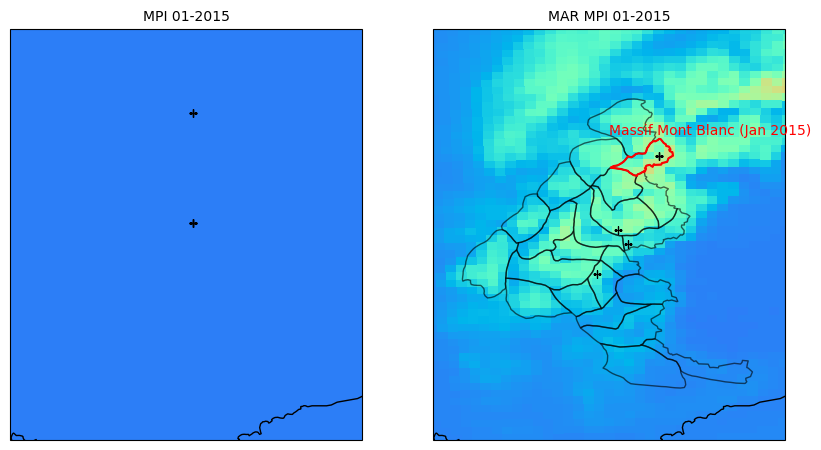

In [54]:
# Plot temperature pour 1er mois
fig, axs = plt.subplots(1, 2, figsize=(10, 6),subplot_kw={'projection': proj},dpi=quality)
#ax = plt.axes(projection=ccrs.PlateCarree())
axs = axs.ravel()

# Latitude and longitude coordinates for gridlines
lat_ticks = np.arange(28, 44, 4)
lon_ticks = np.arange(64, 108, 4)

axs[0].set_title(f'{GCMname} 01-2015',fontsize=10)
axs[1].set_title(f'MAR {GCMname} 01-2015',fontsize=10)

# pcolormesh
m = axs[0].pcolormesh(
    longG, latiG, tmonG[0,0],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)
m = axs[1].pcolormesh(
    longM, latiM, tmonM[0,0],
    cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale, shading='auto' 
)

for i, ax in enumerate(axs):
#ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black') # facecolor='none'
   ax.add_feature(cfeature.COASTLINE)
#axs[1].add_feature(cfeature.COASTLINE)

# Tracé du polygone en pointillés rouge
   ax.plot([4.,16.,16,4,4], [43.,43,48.5,48.5,43], '--r', transform=ccrs.PlateCarree())

   ax.set_xlim(5,8)
   ax.set_ylim(43.5,47)
    
# Position des glaciers (black '+')
for i in range(len(glacioClim)):
    # Data GCM 2 vector coordinates LON & LAT
    # Data MAR 2 matrix coordinates (LON,LAT)
    xG, yG = glacioClXYG[i][1], glacioClXYG[i][2]
    xM, yM = glacioClXYM[i][1], glacioClXYM[i][2]
    axs[0].plot(longG[xG],latiG[yG], marker='+',color='black')
    axs[1].plot(longM[xM][yM],latiM[xM][yM], marker='+',color='black')

# 3. Plot shapefiles massifs alpes
if (True):
    collection = PatchCollection(patches)
    collection.set_color('none')
    collection.set_edgecolor('k')
    collection.set_alpha(0.6)
#    collection1 = PatchCollection(patches)
#    axs[0].add_collection(collection)
    axs[1].add_collection(collection)
#    axs[0].autoscale_view()
print(collection)


# Plot Mont Blanc in red
i_ployg=2 
axs[1].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='red')


axs[1].text(6.5,46.1,f'Massif Mont Blanc (Jan 2015)',color="r")
fig.savefig(f'{path_IMG}{varnameLong}_{GCMname}_Jan_2015.png')

## 5 For a Massif
### 5.1 Create mask for the massif (Mont Blanc)

In [55]:
### ### Number of the glacioclim glacier concerned (ie MdG)
ig=1 #MdG
### ###

In [56]:
### ### Create a mask for the massif 
### 1. Create the polygon
### 2. Create the 2D mask that will contain(lon,lat) at each point mask[i,j] 
### 3. Create a 2D table that will contain the (i,j) at each point table[i,j]
### 4. Fill the mask and the table
### 5. Does the points (lon,lat) are inside the poygon
###   a   Reshape Massif 2D -> 1D 
###   b   Belonging test : True if Inside poygon, False elsewhere 
###   c   Reshape 1D -> 2D
### 6. Update 2D mask and 2D table : values only for massif

# 1. Création du polygone
path = Path(patches[i_ployg].get_xy())
print(longM.shape)
# 2. 3.
Massif2D = np.zeros((91,139,2))
ij_table = np.zeros((91,139,2))
# 4.
for i in range(len(longM[:,0])):
    for j in range(len(longM[0,:])):
        #print(Massif_MB[i,j],[longM[i,j].item(),latiM[i,j].item()])
        Massif2D[i,j,:]=[longM[i,j].item(),latiM[i,j].item()]
        ij_table[i,j,:]=[i,j]

# 5. Test d'appartenance
# 5.a
print("Massif2D.shape",Massif2D.shape)
Massif1D = Massif2D.reshape(91*139,2)
print("Reshaped: Massif1D.shape",Massif1D.shape)
# 5.b
mask1D = path.contains_points(Massif1D)
# 5.c 
mask2D = mask1D.reshape(91,139)
print('1D mask.shape',mask1D.shape)
print('2D mask.shape',mask2D.shape)
#print(mask2D)

# 6. 
inside_points0 = Massif1D[mask1D] # Useless
inside_points_lola = Massif2D[mask2D]
inside_points_ij = ij_table[mask2D]

print('ip_ij',inside_points_ij.shape)
#for lola in inside_points_lola :
#  axs[1].plot(lola[0],lola[1],'+')
    
print(inside_points_ij)

(91, 139)
Massif2D.shape (91, 139, 2)
Reshaped: Massif1D.shape (12649, 2)
1D mask.shape (12649,)
2D mask.shape (91, 139)
ip_ij (14, 2)
[[43. 31.]
 [43. 32.]
 [44. 31.]
 [44. 32.]
 [44. 33.]
 [44. 34.]
 [45. 32.]
 [45. 33.]
 [45. 34.]
 [45. 35.]
 [46. 33.]
 [46. 34.]
 [46. 35.]
 [47. 34.]]


### 5.2 Get MAR and GCM variable and trend for the points of the massif

In [57]:
labelseasons = ["DJF", "MAM", "JJA", "SON"]

### MAR Var

In [58]:
# Initialize : (year,season,points)
# Annual Temperature
MBT_yearG = np.zeros(nby)
MBT_yearM = np.zeros((nby,len(inside_points_ij)))
# Seasonnal Temperature
MBT_seasG = np.zeros((nby,4))
MBT_seasM = np.zeros((nby,len(labelseasons),len(inside_points_ij)))

# Mean Annual Temperature
MBTmean_yearG = 0.
MBTmean_yearM = np.zeros(len(inside_points_ij))
# Mean Seasonnal Temperature
MBTmean_seasG = np.zeros(len(labelseasons))
MBTmean_seasM = np.zeros((len(labelseasons),len(inside_points_ij)))

In [59]:
### Get values:

# Temp and Calculate mean temp for MAR points in the massif

for i in range(len(inside_points_ij)):
    # Data MAR 2 matrix coordinates (LON,LAT)
    #print(inside_points1)
    xM, yM = int(inside_points_ij[i][0]), int(inside_points_ij[i][1])
    # Mean Annual Temp
    MBTmean_yearM[i] = np.average(tyeaM[iy_i:iy_f,yM,xM])
    
    # Annual Temp
    MBT_yearM[:,i] = tyeaM[:,yM,xM]
        
    # Season,nal Temp
    for s in range(4): 
        MBTmean_seasM[s][i] = np.average(tsaiM[iy_i:iy_f,s,yM,xM])

### MAR Trend

In [60]:
# Temperature trend MAR
MBTtrend_yearM = np.zeros((len(inside_points_ij)))
print(MBTtrend_yearM)
# Mean Seasonnal 
MBTtrend_seasM = np.zeros((len(labelseasons),len(inside_points_ij)))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [78]:

### Get values:
for i in range(len(inside_points_ij)):
    xM, yM = int(inside_points_ij[i][0]), int(inside_points_ij[i][1])
    # Fill Ann Temp trend for each point of the massif
    MBTtrend_yearM[i] = slopeT_yM[xM,yM]
    # Fill Season Temp trend
    for s in range(len(labelseasons)):    
        MBTtrend_seasM[s,i] = slopeT_sM[s,xM,yM]
        
print('MBTtrend_yearM',MBTtrend_yearM.shape,'\n',MBTtrend_yearM) ###### MBT_trendM

MBTtrend_yearM (14,) 
 [-0.00029773 -0.00046256 -0.00030233 -0.00027541 -0.00067182 -0.00070987
 -0.00016799 -0.00037303 -0.00060959 -0.00075567 -0.00033693 -0.00031411
 -0.00074825 -0.00043866]


In [83]:
from copy import copy

colo_scale='tab20b'#'terrain'# 'gist_earth'
vmin_scale=500
vmax_scale=3000

Argentiere
Mer de Glace


/var/folders/hx/9_6qztjn4pj086nky0f3801c0000gr/T/ipykernel_8311/220161537.py:33: UserWarning: Adding colorbar to a different Figure <Figure size 1000x500 with 9 Axes> than <Figure size 1000x500 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(cb, ax=axs, orientation="vertical",


Text(0.5, 0.98, 'TOPO (MAR Massif and MAR)')

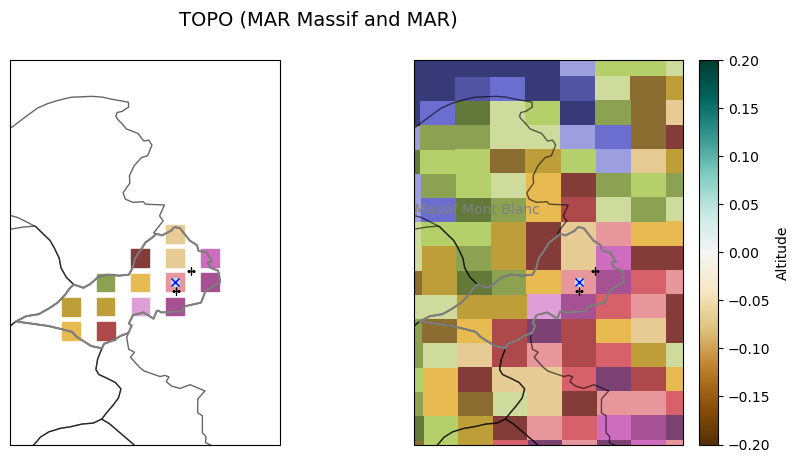

In [84]:
### PLOT TOPO (MAR Massif and MAR) ### CHECK VALUES
# ZOOM
lonZoomMin, lonZoomMax = 5,8
latZoomMin, latZoomMax = 43.5,47
markersize=15
# ZOOM
lonZoomMin, lonZoomMax = 6.5,7.2
latZoomMin, latZoomMax = 45.5,46.5
markersize=160

# Plot TOPO for GCM and MAR
fig, axs = plt.subplots(nrows=1, ncols=2,figsize=(10, 5),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)

# ----- MAR MASSIF -----
ax = axs[0]
    #print("hist",slope_T_hist[i,0,0])
#cb = ax.pcolormesh(longG, latiG, topoMARMassif, 
ax.scatter(inside_points_lola[:,0],inside_points_lola[:,1], c=topoMARMassif, #x,y,z
                   marker='s',s=markersize,
                   cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.add_feature(cfeature.COASTLINE)
    
# ----- MAR -----
ax = axs[1]
    #print("245",slope_T_245[i,0,0])
ax.pcolormesh(longM, latiM, topoMAR,
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.add_feature(cfeature.COASTLINE)

# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("Altitude")

# ----- Titres colonnes -----
#axs[0].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i].yaxis.set_ticks_position('right')
    axs[i].set_ylabel(label, fontsize=14, rotation=90)
    
    axs[i].set_xlim(lonZoomMin, lonZoomMax)
    axs[i].set_ylim(latZoomMin, latZoomMax)

# 3. Plot shapefiles massifs alpes
if (True):
    collection2 = PatchCollection(patches)
    collection2.set_color('none')
    collection2.set_edgecolor('k')
    collection2.set_alpha(0.6)

    #must copy the paches to recreate a new Artist view
    new_patches=copy(patches)
    collection3 = PatchCollection(new_patches)
    collection3.set_color('none')
    collection3.set_edgecolor('k')
    collection3.set_alpha(0.6)
axs[0].add_collection(collection2)
axs[1].add_collection(collection3)

# Plot Mont Blanc in grey
i_ployg=2 
axs[0].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')
axs[1].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')
axs[1].text(6.5,46.1,"Massif Mont Blanc",color='gray')

# Plot Arg
print(glacioClim[0][0])
axs[0].plot(glacioClim[0][1],glacioClim[0][2],'+',color='k') # lon lat
axs[1].plot(glacioClim[0][1],glacioClim[0][2],'+',color='k')
#
i_inMAR,j_inMAR=glacioClXYM[0][1],glacioClXYM[0][2] 
axs[0].plot(longM[i_inMAR,j_inMAR],latiM[i_inMAR,j_inMAR],'o',color='powderblue') # MAR GRID
axs[1].plot(longM[i_inMAR,j_inMAR],latiM[i_inMAR,j_inMAR],'o',color='powderblue')
# Plot MdG
print(glacioClim[1][0])
axs[0].plot(glacioClim[1][1],glacioClim[1][2],'+',color='k')
axs[1].plot(glacioClim[1][1],glacioClim[1][2],'+',color='k')
#
i_inMAR,j_inMAR=glacioClXYM[1][1],glacioClXYM[1][2] 
axs[0].plot(longM[i_inMAR,j_inMAR],latiM[i_inMAR,j_inMAR],'x',color='blue') # MAR GRID
axs[1].plot(longM[i_inMAR,j_inMAR],latiM[i_inMAR,j_inMAR],'x',color='blue')


fig.suptitle(f"TOPO (MAR Massif and MAR)", fontsize=14)
#plt.savefig(f"{path_IMG}MARMassif_TOPO_zoom.png")

In [85]:
# Color scale
colo_scale = 'BrBG'
vmin_scale, vmax_scale = -0.2, 0.2

/var/folders/hx/9_6qztjn4pj086nky0f3801c0000gr/T/ipykernel_8311/2131817797.py:33: UserWarning: Adding colorbar to a different Figure <Figure size 1000x500 with 9 Axes> than <Figure size 1000x500 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(cb, ax=axs, orientation="vertical",


Argentiere
Mer de Glace


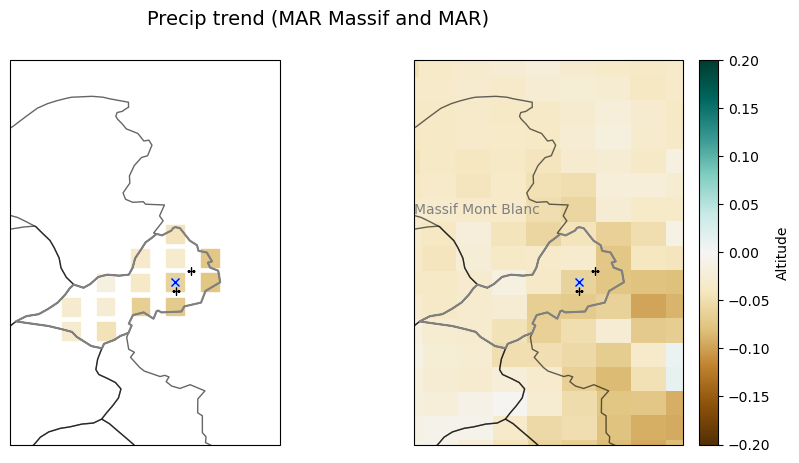

In [86]:
### PLOT PREC TREND (MAR Massif and MAR) ### CHECK VALUES
# ZOOM
lonZoomMin, lonZoomMax = 5,8
latZoomMin, latZoomMax = 43.5,47
markersize=15
# ZOOM
lonZoomMin, lonZoomMax = 6.5,7.2
latZoomMin, latZoomMax = 45.5,46.5
markersize=160

# Plot TOPO for GCM and MAR
fig, axs = plt.subplots(nrows=1, ncols=2,figsize=(10, 5),
    subplot_kw={'projection': proj}, dpi=quality #constrained_layout=True, 
)

# ----- MAR MASSIF -----
ax = axs[0]
    #print("hist",slope_T_hist[i,0,0])
#cb = ax.pcolormesh(longG, latiG, topoMARMassif, 
ax.scatter(inside_points_lola[:,0],inside_points_lola[:,1], c=100*MBTtrend_yearM, #x,y,z  #############################
                   marker='s',s=markersize,
                   cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.add_feature(cfeature.COASTLINE)
    
# ----- MAR -----
ax = axs[1]
    #print("245",slope_T_245[i,0,0])
ax.pcolormesh(longM, latiM, 100*slopeT_yM, #############################
                  cmap=colo_scale, vmin=vmin_scale, vmax=vmax_scale)
ax.add_feature(cfeature.COASTLINE)

# ----- Colorbar globale -----
cbar = fig.colorbar(cb, ax=axs, orientation="vertical",
                    fraction=0.025, pad=0.02)
cbar.set_label("Altitude")

# ----- Titres colonnes -----
#axs[0].set_title(label, fontsize=10)
ax.yaxis.set_ticks_position('left')
# ----- Labels lignes -----
for i, label in enumerate(["GCM", "MAR"]):
    # print(label) !!!! WArning ylabel doesn't appear
    axs[i].yaxis.set_ticks_position('right')
    axs[i].set_ylabel(label, fontsize=14, rotation=90)
    
    axs[i].set_xlim(lonZoomMin, lonZoomMax)
    axs[i].set_ylim(latZoomMin, latZoomMax)

# 3. Plot shapefiles massifs alpes
if (True):
    collection2 = PatchCollection(patches)
    collection2.set_color('none')
    collection2.set_edgecolor('k')
    collection2.set_alpha(0.6)

    #must copy the paches to recreate a new Artist view
    new_patches=copy(patches)
    collection3 = PatchCollection(new_patches)
    collection3.set_color('none')
    collection3.set_edgecolor('k')
    collection3.set_alpha(0.6)
axs[0].add_collection(collection2)
axs[1].add_collection(collection3)

# Plot Mont Blanc in grey
i_ployg=2 
axs[0].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')
axs[1].plot(patches[i_ployg].get_xy()[:, 0],patches[i_ployg].get_xy()[:, 1],color='grey')
axs[1].text(6.5,46.1,"Massif Mont Blanc",color='gray')

# Plot Arg
print(glacioClim[0][0])
axs[0].plot(glacioClim[0][1],glacioClim[0][2],'+',color='k') # lon lat
axs[1].plot(glacioClim[0][1],glacioClim[0][2],'+',color='k')
#
i_inMAR,j_inMAR=glacioClXYM[0][1],glacioClXYM[0][2] 
axs[0].plot(longM[i_inMAR,j_inMAR],latiM[i_inMAR,j_inMAR],'o',color='powderblue') # MAR GRID
axs[1].plot(longM[i_inMAR,j_inMAR],latiM[i_inMAR,j_inMAR],'o',color='powderblue')
# Plot MdG
print(glacioClim[1][0])
axs[0].plot(glacioClim[1][1],glacioClim[1][2],'+',color='k')
axs[1].plot(glacioClim[1][1],glacioClim[1][2],'+',color='k')
#
i_inMAR,j_inMAR=glacioClXYM[1][1],glacioClXYM[1][2] 
axs[0].plot(longM[i_inMAR,j_inMAR],latiM[i_inMAR,j_inMAR],'x',color='blue') # MAR GRID
axs[1].plot(longM[i_inMAR,j_inMAR],latiM[i_inMAR,j_inMAR],'x',color='blue')


fig.suptitle(f"Precip trend (MAR Massif and MAR)", fontsize=14)
plt.savefig(f"{path_IMG}MAR_PrecTrend_zoom.png")

### GCM Temp & Trend

In [62]:
### Get values for GCM
xlonG, ylatG = glacioClXYG[ig][1], glacioClXYG[ig][2] # ig defined above
print(ig, xlonG, ylatG)
print(f'GCM : {glacioClXYG[ig][0]} ij are {xlonG},{ylatG}')

# Annual Temperature trend GCM
MBTtrend_yearG = slopeT_yG[ylatG,xlonG]
print('MBTtrend_yearG:',MBTtrend_yearG)

# Seasonnal Temperature trend GCM
MBTtrend_seasG = np.zeros(len(labelseasons))
for s in range(len(labelseasons)):
        MBTtrend_seasG[s] = slopeT_sG[s,ylatG,xlonG]
print('MBTtrend_seasG:',MBTtrend_seasG)

1 3 4
GCM : Mer de Glace ij are 3,4
MBTtrend_yearG: -0.00019072656147829398
MBTtrend_seasG: [ 0.00155099 -0.00109476 -0.00162733 -0.0009143 ]


### 5.4 Topo

In [63]:
# Open Topo MAR (surface elevation)
wp_Topo_MAR = np.load(path_DIR+'numpyData/topo_MAR_SurfaceH'+'.npz')
print(wp_Topo_MAR)
topoMAR=wp_Topo_MAR['SH']

NpzFile '/Users/peyaudv/Glaciers/MAR_GCMs/numpyData/topo_MAR_SurfaceH.npz' with keys: SH


In [64]:
# Altitude
topoMARMassif = np.zeros((len(inside_points_ij)))
for i in range(len(inside_points_ij)):
    xM, yM = int(inside_points_ij[i][0]), int(inside_points_ij[i][1])
    # Fill Altitude
    topoMARMassif[i] = topoMAR[xM,yM] 

In [65]:
# Topo GCM (surface elevation)
wp_Topo_GCM = np.load(path_DIR+'numpyData/topo_GCM_MPI_SurfaceH'+'.npz')
print(wp_Topo_GCM)
topoGCM=wp_Topo_GCM['SH']

NpzFile '/Users/peyaudv/Glaciers/MAR_GCMs/numpyData/topo_GCM_MPI_SurfaceH.npz' with keys: SH


Plot to check topo (done in temp files)

### 5.4 Plot for all points of MontBlanc Massif

In [66]:
# Same figure with all point in a massif
#For 1 glacier : Mont Blanc
ig=1 # Mer de Glace
print ("glacier: ",glacioClXYG[ii][0])
xG, yG = glacioClXYG[ig][1], glacioClXYG[ig][2]
xM, yM = glacioClXYM[ig][1], glacioClXYM[ig][2]
# Temperature trend GCM
MBT_trendG = slopeT_yG[yG,xG]#[xG,yG]
print(100*MBT_trendG)

glacier:  Mer de Glace
-0.0190726561478294


Mer de Glace 45 34 2449.735


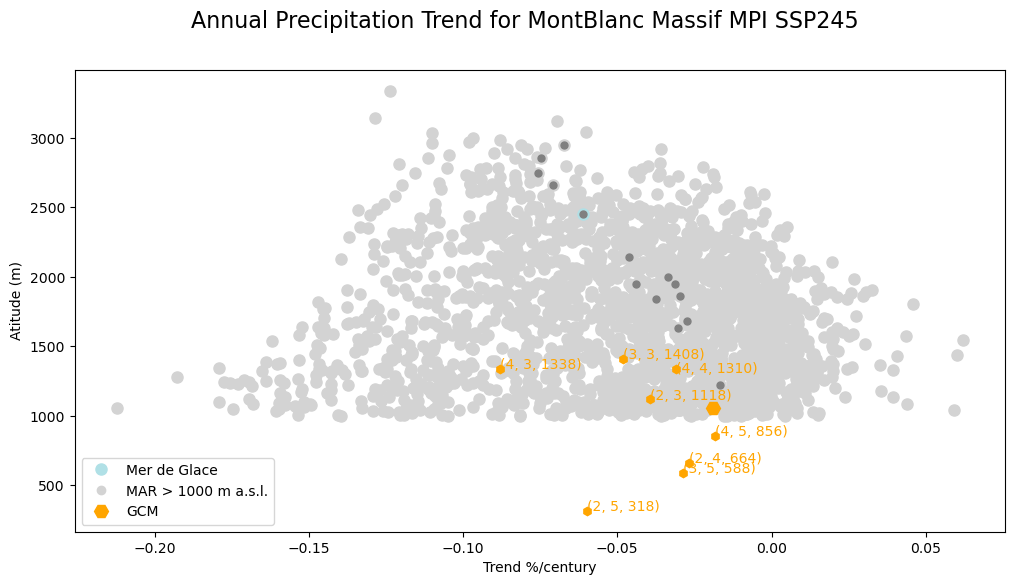

In [88]:
#Plot temperatures mensuelles pour 4 glacier
fig, ax = plt.subplots(1, figsize=(12, 6))
#axs = axs.ravel()

### MAR

# French Alps
for ii in range(20,80):
    for jj in range(10,110):
        if topoMAR[ii, jj] >=1000:
            ax.plot(100*slopeT_yM[ii,jj],topoMAR[ii, jj],'o',ms=8,color='lightgrey')
# MdG
nameM, xM, yM = glacioClXYM[ig][0], glacioClXYM[ig][1],glacioClXYM[ig][2]
print(nameM, xM, yM,topoMAR[xM, yM])
ax.plot(100*slopeT_yM[xM,yM],topoMAR[xM, yM],'o',ms=8,color='powderblue',label=nameM)# !!!!!!!!!!!!!!!!!
# !!!!!!!!!!!!! slopeT_yM[yM,xM] AND topoMAR[xM, yM]


#Mont Blanc
ax.plot(100*MBTtrend_yearM[0],topoMARMassif[0],'o',color='lightgrey',label='MAR > 1000 m a.s.l.')
#ax.plot(100*MBTtrend_yearM[0],topoMARMassif[0]+10,'o',color='red',label='MAR Mont Blanc')
# Loop on all the point of the massif
for pt in range(len(inside_points_ij)): 
    ax.plot(100*MBTtrend_yearM[pt],topoMARMassif[pt],'o',color='grey',ms=5) # -MBTmean_yearM[pt]
    

### GCM  
ax.plot(100*MBTtrend_yearG, topoGCM[ylatG,xlonG],'H',color='orange', ms=10,label='GCM')
#neighbor points
ax.plot(100*slopeT_yG[ylatG-1,xlonG-1], topoGCM[ylatG-1,xlonG-1],color='orange',marker='h')
ax.plot(100*slopeT_yG[ylatG-1,xlonG],   topoGCM[ylatG-1,xlonG],  color='orange',marker='h')
ax.plot(100*slopeT_yG[ylatG-1,xlonG+1], topoGCM[ylatG-1,xlonG+1],color='orange',marker='h')

ax.plot(100*slopeT_yG[ylatG,xlonG-1], topoGCM[ylatG,xlonG-1],color='orange',marker='h')
ax.plot(100*slopeT_yG[ylatG,xlonG+1], topoGCM[ylatG-1,xlonG+1],color='orange',marker='h')

ax.plot(100*slopeT_yG[ylatG+1,xlonG-1], topoGCM[ylatG+1,xlonG-1],color='orange',marker='h')
ax.plot(100*slopeT_yG[ylatG+1,xlonG],   topoGCM[ylatG+1,xlonG],color='orange',marker='h')
ax.plot(100*slopeT_yG[ylatG+1,xlonG+1], topoGCM[ylatG+1,xlonG+1],color='orange',marker='h')

if (True):
    ax.text(100*slopeT_yG[ylatG-1,xlonG-1], topoGCM[ylatG-1,xlonG-1],f'{xlonG-1,ylatG-1,int(topoGCM[ylatG-1,xlonG-1])}',color='orange')
    ax.text(100*slopeT_yG[ylatG-1,xlonG],   topoGCM[ylatG-1,xlonG],  f'{xlonG,ylatG-1,int(topoGCM[ylatG-1,xlonG])}',color='orange')
    ax.text(100*slopeT_yG[ylatG-1,xlonG+1], topoGCM[ylatG-1,xlonG+1],f'{xlonG+1,ylatG-1,int(topoGCM[ylatG-1,xlonG+1])}',color='orange')  

    ax.text(100*slopeT_yG[ylatG,xlonG-1], topoGCM[ylatG,xlonG-1],f'{xlonG-1,ylatG,int(topoGCM[ylatG,xlonG-1])}',color='orange')
    ax.text(100*slopeT_yG[ylatG,xlonG+1], topoGCM[ylatG,xlonG+1],f'{xlonG+1,ylatG,int(topoGCM[ylatG,xlonG+1])}',color='orange')  


    ax.text(100*slopeT_yG[ylatG+1,xlonG-1], topoGCM[ylatG+1,xlonG-1],f'{xlonG-1,ylatG+1,int(topoGCM[ylatG+1,xlonG-1])}',color='orange')
    ax.text(100*slopeT_yG[ylatG+1,xlonG],   topoGCM[ylatG+1,xlonG],  f'{xlonG,ylatG+1,int(topoGCM[ylatG+1,xlonG])}',color='orange')
    ax.text(100*slopeT_yG[ylatG+1,xlonG+1], topoGCM[ylatG+1,xlonG+1],f'{xlonG+1,ylatG+1,int(topoGCM[ylatG+1,xlonG+1])}',color='orange')  
    
ax.set_xlabel('Trend %/century')
ax.set_ylabel('Atitude (m)')
ax.legend(loc='lower left')

fig.suptitle(f"Annual {varnameLong} Trend for MontBlanc Massif {GCMname} {scenario}", fontsize=16)
fig.savefig(f"{path_IMG}Annual{varnameLong}TrendforMontBlancMassif_{GCMname}_{scenario}.png")

### Seasonal plot 

In [68]:
labelseasons = ["DJF", "MAM", "JJA", "SON"]

0 DJF
Mer de Glace 45 34 2449.735
1 MAM
Mer de Glace 45 34 2449.735
2 JJA
Mer de Glace 45 34 2449.735
3 SON
Mer de Glace 45 34 2449.735


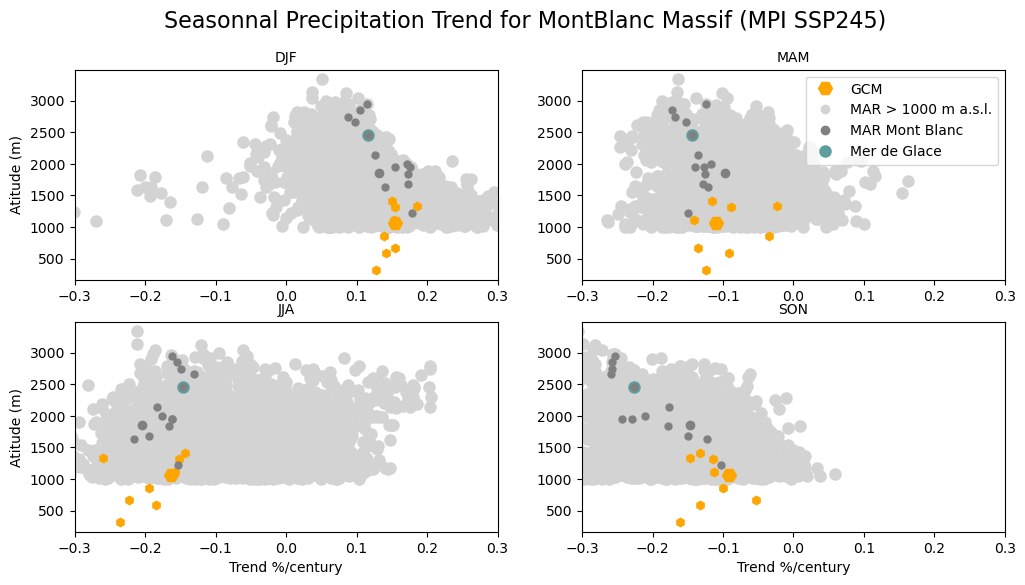

In [91]:
# Figure trend for all point in a massif
#For 1 glacier : Mont Blanc

fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs.ravel()

s = 0 # seasons

for i in range(len(axs)):
    for j in range(len(axs[0])):
        label = labelseasons[s]
        print(s, label)
        ax = axs[i][j]
        ax.set_title(labelseasons[s], fontsize=10)
        
        # MAR
        # French Alps
        for ii in range(20,80):
            for jj in range(10,110):
                if topoMAR[ii, jj] >=1000:
                    ax.plot(100*slopeT_sM[s,ii,jj],topoMAR[ii,jj],'o',ms=8,color='lightgrey')

        # GCM  
        ax.plot(100*MBTtrend_seasG[s], topoGCM[ylatG,xlonG],'H',color='orange', ms=10,label='GCM')  # !!!!!!! # !!!!!!!
        #neighbor points
        ax.plot(100*slopeT_sG[s,ylatG-1,xlonG-1], topoGCM[ylatG-1,xlonG-1],color='orange',marker='h')
        ax.plot(100*slopeT_sG[s,ylatG-1,xlonG],   topoGCM[ylatG-1,xlonG],  color='orange',marker='h')
        ax.plot(100*slopeT_sG[s,ylatG-1,xlonG+1], topoGCM[ylatG-1,xlonG+1],color='orange',marker='h')

        ax.plot(100*slopeT_sG[s,ylatG,xlonG-1],   topoGCM[ylatG,xlonG-1],color='orange',marker='h')
        ax.plot(100*slopeT_sG[s,ylatG,xlonG+1],   topoGCM[ylatG,xlonG+1],color='orange',marker='h')

        ax.plot(100*slopeT_sG[s,ylatG+1,xlonG-1], topoGCM[ylatG+1,xlonG-1],color='orange',marker='h')
        ax.plot(100*slopeT_sG[s,ylatG+1,xlonG],   topoGCM[ylatG+1,xlonG],  color='orange',marker='h')
        ax.plot(100*slopeT_sG[s,ylatG+1,xlonG+1], topoGCM[ylatG+1,xlonG+1],color='orange',marker='h')

              
        # MAR #Mont Blanc
        ax.plot(100*MBTtrend_seasM[s,0],topoMARMassif[0],'o',color='lightgrey',label='MAR > 1000 m a.s.l.')
        ax.plot(100*MBTtrend_seasM[s,0],topoMARMassif[0],'o',color='grey',label='MAR Mont Blanc')
        
        # Arg & MdG
        # ig for MdG defined above
        nameM, xM, yM = glacioClXYM[ig][0], glacioClXYM[ig][1],glacioClXYM[ig][2]
        print(nameM, xM, yM,topoMAR[xM, yM])
        ax.plot(100*slopeT_sM[s,xM,yM],topoMAR[xM, yM],'o',ms=8,color='cadetblue',label=nameM) # !!!!!!!!!!!!!
        ii=1
#        nameM, xM, yM = glacioClXYM[ii][0], glacioClXYM[ii][1],glacioClXYM[ii][2]
#        print(nameM, xM, yM,topoMAR[xM, yM])
#        ax.plot(100*slopeT_sM[s,xM,yM],topoMAR[xM, yM],'o',ms=8,color='powderblue',label=nameM)
        
        # Loop on all the point of the massif
        for pt in range(len(inside_points_ij)): 
            ax.plot(100*MBTtrend_seasM[s,pt],topoMARMassif[pt],'o',color='grey',ms=5)
        
        ax.set_xlim(-.3,.3)
        s=s+1

axs[1,0].set_xlabel('Trend %/century')
axs[1,1].set_xlabel('Trend %/century')
axs[0,0].set_ylabel('Atitude (m)')
axs[1,0].set_ylabel('Atitude (m)')
axs[0,1].legend(loc='upper right') # axs[1,0].legend(loc='upper left')


fig.suptitle(f"Seasonnal {varnameLong} Trend for MontBlanc Massif ({GCMname} {scenario})", fontsize=16)
plt.savefig(f"{path_IMG}{GCMname}-MAR_{scenario}_{varnameShort}_MontBlancMassif_Trend_season.png")